<a href="https://colab.research.google.com/github/turkson-michael/Machine-learning-/blob/main/Pytorch_Computer_Vision_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer vision  Libraries
  - Torchvision - base domain for library
  - Torchvision.datasets- get datasets and data loading functitons
  - torchvision.models- get pretrained computer vision models that you can leverage for your own problems
  - torchvision.transforms- functions for manipulating your vision data (images)  to be suitable for use with a ML model
  - torch.utils.data.Dataset - Base dataset class for Pytorch
  - torch.utils.data.DataLoader- Creates Python iterable over a dataset

In [ ]:
import torch
from torch import nn



# import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor


#import matplotlib
import matplotlib.pyplot as plt


#Check version
print(torch.__version__)
print(torchvision.__version__)

2.8.0+cu126
0.23.0+cu126


In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## Getting a dataset

- The data we are going to use is FAshionMNIST from torchvision.datasets

In [ ]:
#Setup training data

from torchvision import datasets


train_data = datasets.FashionMNIST(
    root='data', #Where to download data to?
    train = True , #do we want traububg datasets?
    download=True, #do we want to download yes/no?
    transform= torchvision.transforms.ToTensor(), #how do we want to transform the data?
    target_transform=None # how do we want to transform the target?
)


test_data = datasets.FashionMNIST(
    root='data', #Where to download data to?
    train = False , #do we want traububg datasets?
    download=True, #do we want to download yes/no?
    transform= torchvision.transforms.ToTensor(), #how do we want to transform the data?
    target_transform=None # how do we want to transform the target?
)


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.06MB/s]


In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
# See first training example

image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [ ]:
#Check the shape of our image
image.shape, label

(torch.Size([1, 28, 28]), 9)

In [ ]:
print(f'image shape: {image.shape} -> [color_channels, height, width]')

image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]


In [ ]:
print(f'image label: {class_names[label]}')

image label: Ankle boot


## Visualize !!!!!

image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

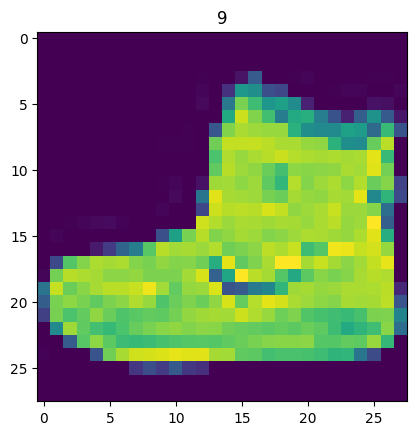

In [ ]:
image, label = train_data[0]

print(f'image shape: {image.shape}')
plt.imshow(image.squeeze()) #Removes the color
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

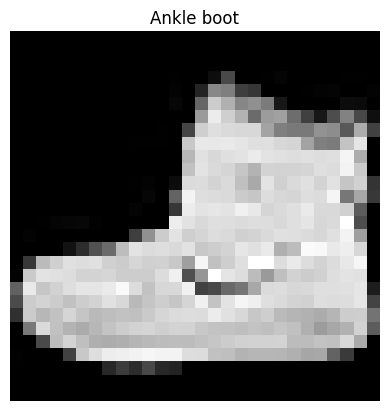

In [ ]:
plt.imshow(image.squeeze(), cmap='gray')
plt.title(class_names[label])
plt.axis(False)

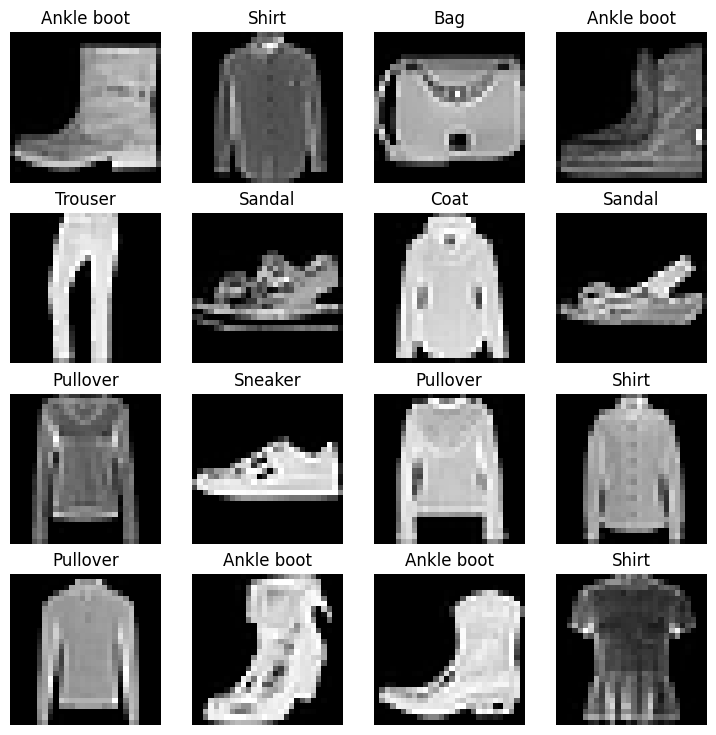

In [ ]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4,4
for i in range(1, rows*cols +1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  #print(random_idx)
  img, label = train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(), cmap='gray')
  plt.title(class_names[label])
  plt.axis(False);

## Prepare DataLoader
- Right now, our data is in the form of PyTorch DataSets
- DataLoader turns our datasets into python iterable
- Also, we want to turn our data into mini-batches because
              1. its more computationally efficient
              2. it gives our neural network more chances to updates its gradient per epoch


In [ ]:
from torch.utils.data import DataLoader

#Setup the batch size
BATCH_SIZE = 32


#tURN datasets into batches
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader= DataLoader(
    dataset= test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7d7c88ecb9b0>,
 <torch.utils.data.dataloader.DataLoader at 0x7d7c88d45d30>)

In [ ]:
#Lets check out what we created
print(f'DataLoader: {train_dataloader, test_dataloader}')
print(f'Length of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}.....')
print(f'Length of test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}...')

DataLoader: (<torch.utils.data.dataloader.DataLoader object at 0x7d7c88ecb9b0>, <torch.utils.data.dataloader.DataLoader object at 0x7d7c88d45d30>)
Length of train_dataloader: 1875 batches of 32.....
Length of test_dataloader: 313 batches of 32...


In [ ]:
# Check out what is inside training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

image size: torch.Size([1, 28, 28])
Label: 8,label size: torch.Size([])


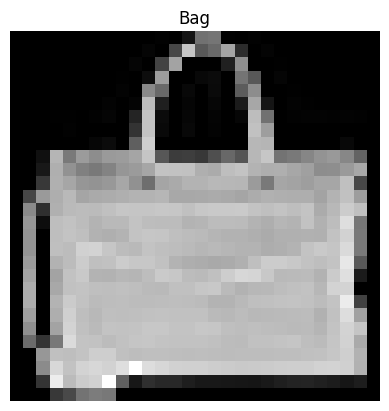

In [ ]:
# Show a sample
#torch.manual_seed(42)

random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(),cmap='gray')
plt.title(class_names[label])
plt.axis(False)
print(f'image size: {img.shape}')
print(f'Label: {label},label size: {label.shape}')

## BUILD BASELINE MODEL

In [ ]:
#Create a flatten layer

flatten_model = nn.Flatten()


#Get a single sample
x = train_features_batch[0]
x.shape



#Flatten the sample
output = flatten_model(x) #Perform forward pass

#Print out
print(f'Shape before flattening: {x.shape}-> [color_channels, height, width]')
print(f'Shape after flattening: {output.shape} -> [color_channels, height *width]')
#

Shape before flattening: torch.Size([1, 28, 28])-> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height *width]


In [ ]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )


  def forward(self,x):
    return self.layer_stack(x)



In [ ]:
torch.manual_seed(42)


#Setup model with input parameters
model_0 = FashionMNISTModelV0(input_shape=784, # 28 * 28
                               hidden_units=10,
                               output_shape=len(class_names))



model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

### Setup loss ,optimizer and evaluation metrics

In [ ]:
import requests

from pathlib import Path


In [ ]:
from pathlib import Path

#Download helper functions from Learn Pytorch repo (if its not already downloaded)

if Path("helper_functions.py").is_file():
  print('helper functions.py already exists, skipping download')
else:
  print('Download helper_functions.py')
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

Download helper_functions.py


In [ ]:
#Import accuracy metric

from helper_functions import accuracy_fn


#Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

### Time our experiments


In [ ]:
from timeit  import default_timer as timer
from tqdm.auto import tqdm


def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [ ]:
start_time = timer()
#put code here


end_time = timer()

print_train_time(start=start_time,
                 end=end_time,
                 device='cpu')

Train time on cpu: 0.000 seconds


6.257600000481034e-05

### Creating a training loop
1. loop through epochs
2. loop through training batches, perform training steps, calculate train loss
3. loop through testing batches,perform testing steps, calculate test losss
4. print out
5. time it all

In [ ]:
#import tqdm for progress bar
from tqdm.auto import tqdm

#Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()


#Set number of epochs
epochs = 3

#Create training and test loop
for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n-------')

  ##Training
  train_loss = 0
  #Add a loop to loop through the training batches
  for batch, (X,y) in enumerate(train_dataloader):
    model_0.train()
    #1. forward pass
    y_pred = model_0(X)

    #2. calculate the loss (per batch)
    loss = loss_fn(y_pred, y)
    train_loss += loss #Accumulate train loss

    #3. optimizer zero grad
    optimizer.zero_grad()

    #4. loss backwards
    loss.backward()


    #5. optimizer step
    optimizer.step()

    #Print out
    if batch % 400 == 0:
      print(f'Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples')

  # Divide total train loss by length of train dataloader
  train_loss /= len(train_dataloader)


  ### Testing
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X_test,y_test in test_dataloader:
      #1. forward pass
      test_pred = model_0(X_test)

      #2. Calculate the loss (accumulatively)
      test_loss += loss_fn(test_pred, y_test)

      #3. Calculate the accuracy (accumulatively)
      batch_acc = accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))
      test_acc += batch_acc if isinstance(test_acc, torch.Tensor) else torch.tensor(batch_acc)


  #Calculate the test loss average per batch
  test_loss = test_loss.clone() / len(test_dataloader)

  #Calculate the test accuracy average per batch
  test_acc = test_acc.clone() / len(test_dataloader)

  #Print out
  print(f'Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}')


#Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                          end=train_time_end_on_cpu,
                                          device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.59039 | Test loss: 0.50954 | Test acc: 82.04
Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.47633 | Test loss: 0.47989 | Test acc: 83.20
Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.45503 | Test loss: 0.47664 | Test acc: 83.43
Train time on cpu: 34.330 seconds


### Send model to target device

In [ ]:
next(model_0.parameters()).device

device(type='cpu')

In [ ]:

'''
#import tqdm for progress bar
from tqdm.auto import tqdm

#Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()


#Set number of epochs
epochs = 3

#Create training and test loop
for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n-------')

  ##Training
  train_loss = 0
  #Add a loop to loop through the training batches
  for batch, (X,y) in enumerate(train_dataloader):
    model_0.train()
    #1. forward pass
    y_pred = model_0(X)

    #2. calculate the loss (per batch)
    loss = loss_fn(y_pred, y)
    train_loss += loss #Accumulate train loss

    #3. optimizer zero grad
    optimizer.zero_grad()

    #4. loss backwards
    loss.backward()


    #5. optimizer step
    optimizer.step()

    #Print out
    if batch % 400 == 0:
      print(f'Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples')

    # Divide total train loss by length of train dataloader
    train_loss /= len(train_dataloader)


    ### Testing
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
      for X_test,y_test in test_dataloader:
        #1. forward pass
        test_pred = model_0(X_test)

        #2. Calculate the loss (accumulatively)
        test_loss += loss_fn(test_pred, y_test)

        #3. Calculate the accuracy (accumulatively)
        test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))

    #Calculate the test loss average per batch
    test_loss /= len(test_dataloader)

    #Calculate the test accuracy average per batch
    test_acc /= len(test_dataloader)

  #Print out
  print(f'Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}')


  #Calculate training time
  train_time_end_on_cpu = timer()
  total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                            end=train_time_end_on_cpu,
                                            device=str(next(model_0.parameters()).device))
'''

"\n#import tqdm for progress bar\nfrom tqdm.auto import tqdm\n\n#Set the seed and start the timer\ntorch.manual_seed(42)\ntrain_time_start_on_cpu = timer()\n\n\n#Set number of epochs\nepochs = 3\n\n#Create training and test loop\nfor epoch in tqdm(range(epochs)):\n  print(f'Epoch: {epoch}\n-------')\n\n  ##Training\n  train_loss = 0\n  #Add a loop to loop through the training batches\n  for batch, (X,y) in enumerate(train_dataloader):\n    model_0.train()\n    #1. forward pass\n    y_pred = model_0(X)\n\n    #2. calculate the loss (per batch)\n    loss = loss_fn(y_pred, y)\n    train_loss += loss #Accumulate train loss\n\n    #3. optimizer zero grad\n    optimizer.zero_grad()\n\n    #4. loss backwards\n    loss.backward()\n\n\n    #5. optimizer step\n    optimizer.step()\n\n    #Print out\n    if batch % 400 == 0:\n      print(f'Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples')\n\n    # Divide total train loss by length of train dataloader\n    train_loss /= len(trai

### Making prediction

In [ ]:
torch.manual_seed(42)

def eval_mode(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn):
  loss,acc = 0,0
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      #Make predictions
      y_pred = model(X)

      #Accumulate loss and acc values per batch
      loss += loss_fn(y_pred,y)
      acc += accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))

    #Scale loss and acc to find average loss/acc per batch
    loss /= len(data_loader)
    acc /=len(data_loader)

  return {'model_name': model.__class__.__name__,
          'model_loss': loss.item(),
          'model_acc': acc}


#Calculate model 0  result on test dataset
model_0_results = eval_mode(model=model_0,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## Building with non-linearity

In [ ]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=input_shape,
                out_features=hidden_units),
      nn.ReLU(),
      nn.Linear(in_features=hidden_units,
                out_features=output_shape)
    )

  def forward(self,x: torch.Tensor):
    return self.layer_stack(x)


In [ ]:
torch.manual_seed(42)

model_1 = FashionMNISTModelV1(input_shape=784,
                              hidden_units=10,
                              output_shape=len(class_names))

model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
  )
)

### SETUP LOSS, OPTIMIZER AND EVALUATION METRICS

In [ ]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

### Training and testing loop

In [ ]:
def train_step(
    model:torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn,
    device: torch.device = None
):

  train_loss, train_acc = 0,0
  model.train()

  ##Training
  train_loss = 0
  #Add a loop to loop through the training batches
  for batch, (X,y) in enumerate(train_dataloader):
    model.train()
    #1. forward pass
    y_pred = model(X)

    #2. calculate the loss (per batch), accuracy per batch
    loss = loss_fn(y_pred, y)
    train_loss += loss #Accumulate train loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    #3. optimizer zero grad
    optimizer.zero_grad()

    #4. loss backwards
    loss.backward()


    #5. optimizer step
    optimizer.step()

  #divide total train loss  and acc
  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  #Print out
  print(f'Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%')

  return {'train_loss': train_loss.item(),
          'train_acc': train_acc}



In [ ]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = None):

  test_loss, test_acc = 0,0

  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      #Make predictions
      y_pred = model(X)

      #Accumulate loss and acc values per batch
      test_loss += loss_fn(y_pred,y)
      test_acc += accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))

    #Scale loss and acc to find average loss/acc per batch
    test_loss /= len(data_loader)
    test_acc /=len(data_loader)
    print(f'Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%')



In [ ]:
torch.manual_seed(42)

#measure time
from timeit import default_timer as timer
train_time_start_on_cpu = timer()


#set epochs
epochs=3

#Create optimizer and evaluation loop
for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n-------')
  train_step(model=model_1,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn)

  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn)


train_time_end_on_cpu=timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_cpu,
                                            end=train_time_end_on_cpu,
                                            device=str(next(model_1.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.64607 | Train acc: 77.17%
Test loss: 0.53855 | Test acc: 80.76%
Epoch: 1
-------
Train loss: 0.48094 | Train acc: 82.94%
Test loss: 0.49390 | Test acc: 82.46%
Epoch: 2
-------
Train loss: 0.44689 | Train acc: 84.16%
Test loss: 0.45746 | Test acc: 83.99%
Train time on cpu: 44.405 seconds


In [ ]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [ ]:
# Get model_1 results dictionary

model_1_results = eval_mode(model=model_1,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn,
                            )
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.45746350288391113,
 'model_acc': 83.98562300319489}

## Building CNN

In [ ]:
# Create CNN

class FashionMNISTModelV2(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     )
    )
    self.conv_block_2 = nn.Sequential(
       nn.Conv2d(in_channels=hidden_units,
                 out_channels=hidden_units,
                 kernel_size=3,
                 stride=1,
                 padding=1),
       nn.ReLU(),
       nn.Conv2d(in_channels=hidden_units,
                 out_channels=hidden_units,
                 kernel_size=3,
                 stride=1,
                 padding=1),
       nn.ReLU(),
       nn.MaxPool2d(kernel_size=2)
    )
    print(f"Calculated in_features for linear layer: {hidden_units*7*7}") # Added print
    print(f"Output shape for linear layer: {output_shape}") # Added print
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
        )

  def forward(self,x):
    x = self.conv_block_1(x)
    #print(f'Output shape of conv_block_1: {x.shape}')
    x = self.conv_block_2(x)
    #print(f'Output shape of conv_block_2: {x.shape}')
    x = self.classifier(x)
    #print(f'Output shape of classifier: {x.shape}')
    return x

In [ ]:
torch.manual_seed(42)

model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_units=10,
                              output_shape=len(class_names))

model_2

Calculated in_features for linear layer: 490
Output shape for linear layer: 10


FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

### Stepping through Conv2d

In [ ]:
torch.manual_seed(42)

#Create a batch of images
images = torch.randn(size=(32,3,64,64))

test_image = images[0]

print(f'image batch shape: {images.shape}')
print(f'single image shape: {test_image.shape}')
print(f'single image channel shape: {test_image[0].shape}')

image batch shape: torch.Size([32, 3, 64, 64])
single image shape: torch.Size([3, 64, 64])
single image channel shape: torch.Size([64, 64])


In [ ]:
torch.manual_seed(42)
# Create a single conv2d layer
conv_layer = nn.Conv2d(in_channels=3,
                         out_channels=10,
                         kernel_size=3,
                         stride=1,
                         padding=0)


#Pass data to conv layer
conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 62, 62])

In [ ]:
# Steppping through maxpool2d

test_image.shape

torch.Size([3, 64, 64])

In [ ]:
# print out original image shape without unsqueezed dimension

print(f'test image original shape: {test_image.shape}')
print(f'test image unsqueezed shape: {test_image.unsqueeze(dim=0).shape}')


#Create a sample nn.Maxpoool2d
max_pool_layer = nn.MaxPool2d(kernel_size=2)

#pass data through nn.Maxpool2d
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f'test image through conv shape: {test_image_through_conv.shape}')


#Pass data through the maxpool layer
test_image_through_conv_maxpool = max_pool_layer(test_image_through_conv)
print(f'test image through conv maxpool shape: {test_image_through_conv_maxpool.shape}')

test image original shape: torch.Size([3, 64, 64])
test image unsqueezed shape: torch.Size([1, 3, 64, 64])
test image through conv shape: torch.Size([1, 10, 62, 62])
test image through conv maxpool shape: torch.Size([1, 10, 31, 31])


In [ ]:
torch.manual_seed(42)

#Create a random tensor with similar number of dimensions

random_tensor = torch.randn(size=(1,1,2,2))

#Create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

#Pass data through the maxpool layer
max_pool_tensor = max_pool_layer(random_tensor)

print(f'random tensor: {random_tensor}')
print(f'random tensor shape: {random_tensor.shape}')
print(f'max pool tensor: {max_pool_tensor}')
print(f'max pool tensor shape: {max_pool_tensor.shape}')


random tensor: tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
random tensor shape: torch.Size([1, 1, 2, 2])
max pool tensor: tensor([[[[0.3367]]]])
max pool tensor shape: torch.Size([1, 1, 1, 1])


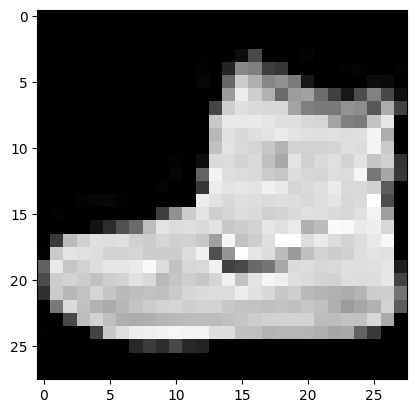

In [ ]:
plt.imshow(image.squeeze(), cmap='gray')

In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
rand_image_tensor = torch.randn(size=(1,28,28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [ ]:
model_2(rand_image_tensor.unsqueeze(dim=0).to(device=device))

tensor([[ 0.0424, -0.0839,  0.0839, -0.0463,  0.0053,  0.0437,  0.0025,  0.0108,
         -0.0158, -0.0177]], grad_fn=<AddmmBackward0>)

In [ ]:
# Move model to target device
model_2.to(device)
model_2(rand_image_tensor.unsqueeze(dim=0).to(device=device))

tensor([[ 0.0424, -0.0839,  0.0839, -0.0463,  0.0053,  0.0437,  0.0025,  0.0108,
         -0.0158, -0.0177]], grad_fn=<AddmmBackward0>)

## TRaining our model

### SEtup loss and optimizer

In [ ]:
#Setup loss function/eval

from helper_functions import accuracy_fn

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

### Training our model

In [ ]:
#We created our train and test functions


torch.manual_seed(42)


#measure time
from timeit import default_timer as Timer
train_time_start_model_2 = timer()



#Train and  test model
epochs = 3

for epoch in tqdm(range(epochs)):
  print(f'Epoch: {epoch}\n-------')
  train_step(model=model_2,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device = device)

  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)


train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                            end=train_time_end_model_2,
                                            device=str(next(model_2.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.59518 | Train acc: 78.38%
Test loss: 0.39500 | Test acc: 85.99%
Epoch: 1
-------
Train loss: 0.36536 | Train acc: 86.90%
Test loss: 0.35244 | Test acc: 86.91%
Epoch: 2
-------
Train loss: 0.32588 | Train acc: 88.13%
Test loss: 0.32719 | Test acc: 88.07%
Train time on cpu: 196.899 seconds


In [ ]:
# Get model_2 results

model_2_results = eval_mode(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)


model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

In [ ]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [ ]:
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.45746350288391113,
 'model_acc': 83.98562300319489}

## Evaluation metrics

In [ ]:
import pandas as pd

compare_results = pd.DataFrame([model_0_results,
                                model_1_results,
                               model_2_results])

compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.457464,83.985623
2,FashionMNISTModelV2,0.327190,88.069089


In [ ]:
# Add training time to results comparison

compare_results['training_time'] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]

compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,34.329536
1,FashionMNISTModelV1,0.457464,83.985623,44.405008
2,FashionMNISTModelV2,0.327190,88.069089,196.899117


## Visualise our model results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,34.329536
1,FashionMNISTModelV1,0.457464,83.985623,44.405008
2,FashionMNISTModelV2,0.327190,88.069089,196.899117


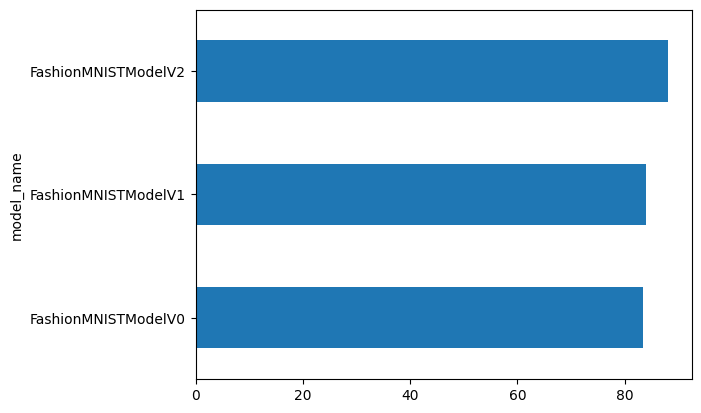

In [ ]:
compare_results.set_index('model_name')['model_acc'].plot(kind='barh')
plt.xlabel('accuracy')
plt.ylabel('model')

In [ ]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
  pred_probs = [] # Initialize as a list
  model.eval()
  with torch.inference_mode():
    for sample in data:
      #Prepare the sample (add a batch dimension and pass to target device)
      sample = torch.unsqueeze(sample, dim=0).to(device)

      #Forward pass
      pred_logit = model(sample)

      #Get preds probs
      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # Use a different variable name

      #Get pred_prob off GPU and append to list
      pred_probs.append(pred_prob.cpu()) # Append to the list


    #Stack the pred probs to turn list into tensor
    return torch.stack(pred_probs)

In [ ]:
import random
#random.seed(42)

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

#View the first sample shape
test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Sandal')

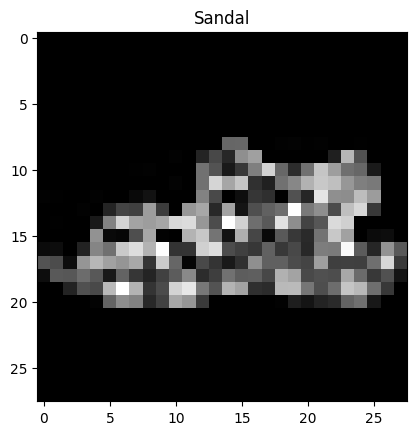

In [ ]:
plt.imshow(test_samples[0].squeeze(), cmap='gray')
plt.title(class_names[test_labels[0]])

In [ ]:
# Make predictions

pred_probs = make_predictions(model=model_2,
                              data=test_samples)

#View first two prediction probabilities
pred_probs[:2]

tensor([[4.8985e-06, 3.8091e-06, 1.7598e-05, 7.9796e-05, 4.0330e-05, 9.9875e-01,
         1.4651e-05, 5.5126e-04, 1.0631e-04, 4.2633e-04],
        [6.8429e-03, 3.5319e-05, 9.3410e-02, 5.7107e-03, 2.0758e-01, 2.2226e-05,
         6.8609e-01, 1.6528e-05, 2.5366e-04, 4.0201e-05]])

In [ ]:
#Convert prediction prob to labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 6, 6, 4, 3, 1, 2, 3, 6])

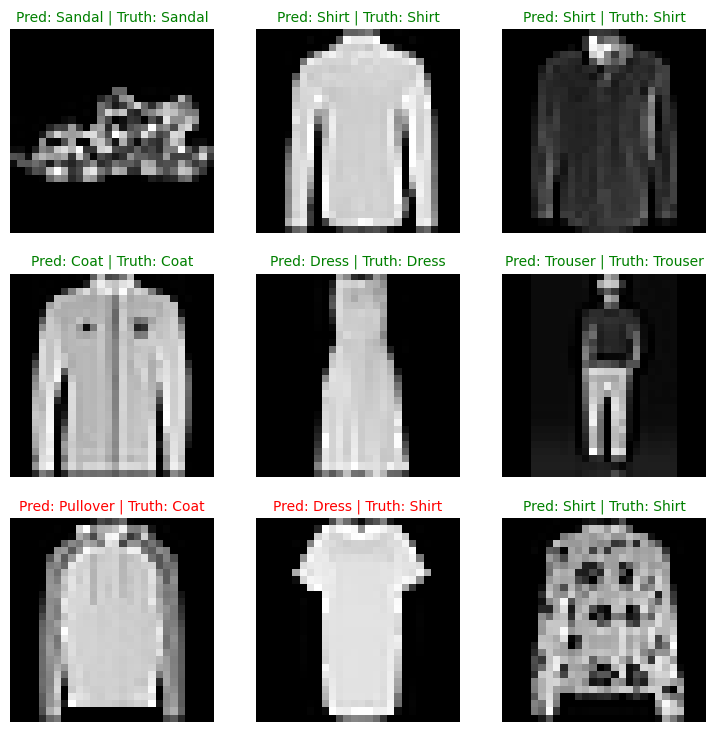

In [ ]:
#Plot predictions
plt.figure(figsize=(9,9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)

  #Plot target image
  plt.imshow(sample.squeeze(), cmap='gray')

  #Find predictions (in text form)
  pred_label = class_names[pred_classes[i]]

  #Get truth label
  truth_label = class_names[test_labels[i]]

  #Create a title for the plot
  title_text = f'Pred: {pred_label} | Truth: {truth_label}'

  #Check for equality between pred and truth and change color of title text
  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, color='green')
  else:
    plt.title(title_text, fontsize=10, color='red')
    #title_text = f'Pred: {pred_label} | Truth: {truth_label}'
  plt.axis(False)

### Confusion matrix

In [ ]:
from tqdm.auto import tqdm


#Make prediction with trained model
y_preds = [] # Initialize as a list
model_2.eval()
with torch.inference_mode():
  for X,y in tqdm(test_dataloader, desc='Making predictions....'):
    X,y = X.to(device), y.to(device)

    #Forward pass
    y_logits = model_2(X)
    #Turn predictions from logits to labels
    y_pred = torch.softmax(y_logits.squeeze(), dim=0).argmax(dim=1)

    #Put predictions on cpu for evaluation
    y_preds.append(y_pred.cpu()) # Append to the list

  #Concatenate list of predictions into tensor
  #print(y_preds) # Commented out print
  y_pred_tensor = torch.cat(y_preds)
  y_pred_tensor[:10] # Commented out display of the first 10 elements

Making predictions....:   0%|          | 0/313 [00:00<?, ?it/s]

In [ ]:
len(y_pred_tensor)

10000

In [ ]:
#see if required packages are installed and if not ,install them
try:
  import torchmetrics, mlxtend # Corrected mixtend to mlxtend
  print(f'mlxtend version: {mlxtend.__version__}')
  assert int(mlxtend.__version__.split(".")[1]) >= 19, 'mlxtend version should be 19 or higher' # Corrected mixtend to mlxtend and simplified assert
except:
  !pip install -q torchmetrics -U mlxtend
  import torchmetrics, mlxtend # Import again after installing
  print(f'mlxtend version: {mlxtend.__version__}')

mlxtend version: 0.23.4


In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

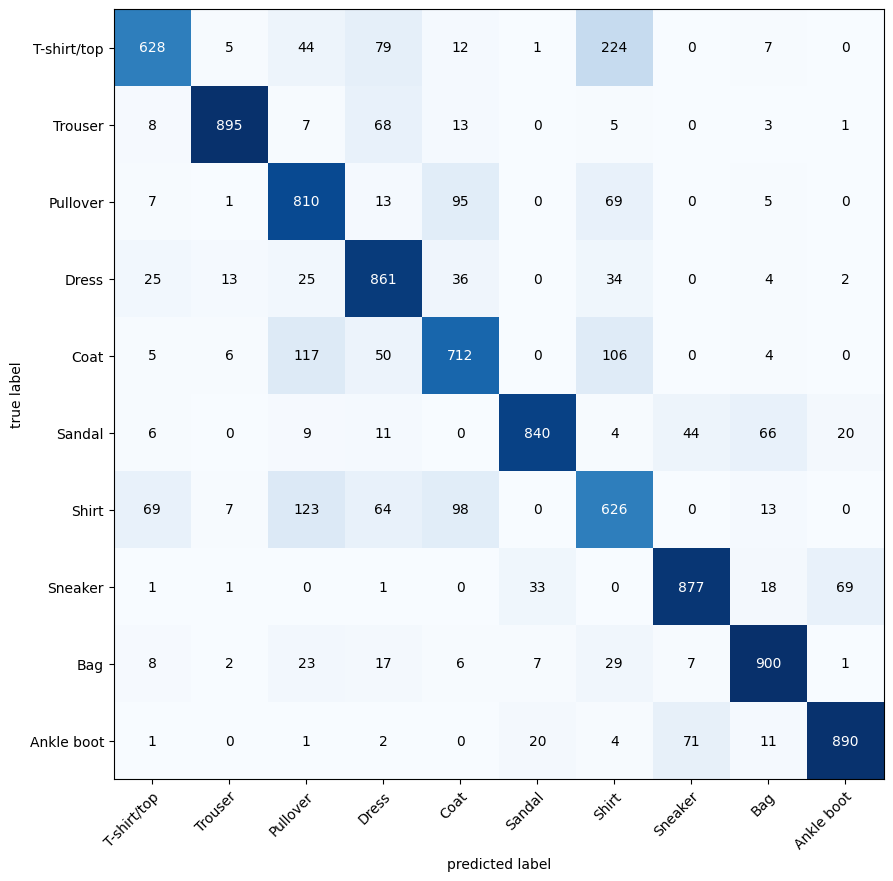

In [ ]:
confmat = ConfusionMatrix(num_classes=len(class_names),
                          task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

#Plot confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy(),
    class_names = class_names,
    figsize=(10,10)
)

# Save and reload model

In [ ]:
from pathlib import Path

#Create model dictionary path
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True)

#Create model save
MODEL_NAME = "Pytorch computer vision_model_2"
MODEL_SAVE_PATH = MODEL_PATH/ MODEL_NAME

#Save the model state dict
print(f'Saving model to: {MODEL_SAVE_PATH}')
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)
#

Saving model to: models/Pytorch computer vision_model_2


In [ ]:
image_shape = [1,28,28]



In [ ]:
#Creeate a new instance
torch.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                     hidden_units=10,
                                     output_shape=len(class_names))



#load in the save dict ()

loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))



#sEND TO TARGGET DEVICE
loaded_model_2.to(device)

Calculated in_features for linear layer: 490
Output shape for linear layer: 10


FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

In [ ]:
# EValuate loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_mode(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn = accuracy_fn
)

loaded_model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

In [ ]:
# check if model results are close
torch.allclose(torch.tensor(model_2_results['model_loss']),
              torch.tensor(loaded_model_2_results['model_loss']),
              atol=1e-03)

True